# Morphological Segmentation

The goal of this notebook is produce morphological segmentations for two languages:

- Rarámuri (Tahumara) [tar], an indigenous language of Northern Mexico that is part of the Uto-Aztecan language family.
- Shipibo-Konibo [shp], a Panoan language of the Peruvian Amazon.

We'll first try an information-theoretic approach (e.g. BPE, WordPiece, etc.) and then machine learning methods (e.g. throw a transformer at the problem).

The baselines we want to beat:

For shp: 

- Morfessor: 0.3207

- BPE: 0.2682

- Unigram: 0.2616

For tar:

- Morfessor: 0.2959

- BPE: 0.4213

- Unigram: 0.3369

In [33]:
import os
import math
import numpy as np
from eval import run_eval
from preprocess import clean_target_segmentation
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
def load_lines(filepath):
    with open(filepath, encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

# load data
languages = ['shp', 'tar']              # 'shp' = Shipibo-Konibo, 'tar' = Rarámuri
splits = ['train', 'dev', 'test']       
data = {}

# Set this flag to enable/disable "cleaning" of target segmentations
# e.g. remove additional characters from target segmentations

PREPROCESS_TGT = True

for lang in languages:
    data[lang] = {}
    for split in splits:
        data[lang][split] = {}
        
        # load source file (unsegmented words)
        src_file = os.path.join('dataset', f'{lang}.{split}.src')
        if os.path.exists(src_file):
            data[lang][split]['src'] = load_lines(src_file)
            
        # load target file (morphological segmentations) if exists
        tgt_file = os.path.join('dataset', f'{lang}.{split}.tgt')
        if os.path.exists(tgt_file):
            data[lang][split]['tgt'] = load_lines(tgt_file)

if PREPROCESS_TGT:
    for lang in data:
        for split in data[lang]:
            if 'src' in data[lang][split] and 'tgt' in data[lang][split]:
                new_tgt = []
                for src_word, tgt_line in zip(data[lang][split]['src'], data[lang][split]['tgt']):
                    cleaned = clean_target_segmentation(src_word, tgt_line)
                    new_tgt.append(" ".join(cleaned))
                data[lang][split]['tgt'] = new_tgt
    print("Target segmentations cleaned.")

Target segmentations cleaned.


In [16]:
# check data is loaded correctly

for lang in languages:
    for split in splits:
        if 'src' in data[lang][split] and 'tgt' in data[lang][split]:
            assert len(data[lang][split]['src']) == len(data[lang][split]['tgt'])
    print(f'{lang} is loaded correctly.')
        
print()
# print example for both languages of src and tgt

for lang in languages:
    for split in ['train']:
        print(f'{lang}.{split}')
        for i in range(3):
            print(f'    {data[lang][split]["src"][i]}')
            print(f'    {data[lang][split]["tgt"][i]}')
            print()

shp is loaded correctly.
tar is loaded correctly.

shp.train
    yoyoaibata
    yoyoa ibat a

    kotsatax
    kotsat ax

    bokasai
    bo kas ai

tar.train
    páa
    páa

    pochítisi
    pochí ti si

    konári
    ko nári



# Information-Theoretic Approaches

The idea here is to use conditional entropy. Morphemes are the smallest meaningful units of letters. Then from an information-theoretic standpoint, subsets of letters carry some information about the set of possible morphemes they could form. As you add letters to a sequence, the available set of candidate morphemes narrows, meaning the information content—or uncertainty—decreases until it eventually reaches zero. In practice, we calculate the surprisal of a letter with

$$
S = -\log P(x_i \mid x_{i-1}),
$$

and when this surprisal value exceeds a certain threshold, it tells  that the next letter is unexpectedly out of line with the current pattern, suggesting a natural morpheme boundary.

In [53]:
# conditional entropy segmentation using character-level n-gram model
class NGramModel:
    def __init__(self, n=4, smoothing_constant=1.0, surprisal_threshold=-3):
        self.n = n
        self.smoothing_constant = smoothing_constant
        self.ngram_counts = defaultdict(lambda: defaultdict(int))
        self.prefix_counts = defaultdict(int)
        self.vocabulary = set()
        self.surprisal_threshold = surprisal_threshold

    def fit(self, words):
        # build n-gram model from list of words
        for word in words:
            word += '<END>'  # Append end of word symbol
            for i in range(len(word)):
                # collect counts for n-grams and their prefixes
                for j in range(1, min(self.n + 1, i + 2)):
                    ngram = word[i - j + 1:i + 1]
                    prefix = ngram[:-1]
                    self.ngram_counts[prefix][ngram[-1]] += 1
                    self.prefix_counts[prefix] += 1
                self.vocabulary.add(word[i])

    def next_letter_log_probability(self, prefix, char):
        # calculate smoothed log probability of a character given a prefix
        ngram_count = self.ngram_counts[prefix][char]
        prefix_count = self.prefix_counts[prefix]
        vocab_size = len(self.vocabulary)
        smoothed_prob = (ngram_count + self.smoothing_constant) / (prefix_count + self.smoothing_constant * vocab_size)
        return math.log(smoothed_prob)

    def segment_word(self, word):
        # segment word based on surprisal
        segments = []
        start = 0
        for i in range(1, len(word) + 1):
            partial_morpheme = word[start:i]
            if len(partial_morpheme) < self.n:
                continue

            if i < len(word):
                next_char = word[i]
                prefix = partial_morpheme[-(self.n - 1):]
                log_prob_next_char = self.next_letter_log_probability(prefix, next_char)

                # check for high surprise (low probability of next letter)
                if log_prob_next_char < self.surprisal_threshold:
                    segments.append(partial_morpheme)
                    start = i

        segments.append(word[start:])
        return " ".join(segments)

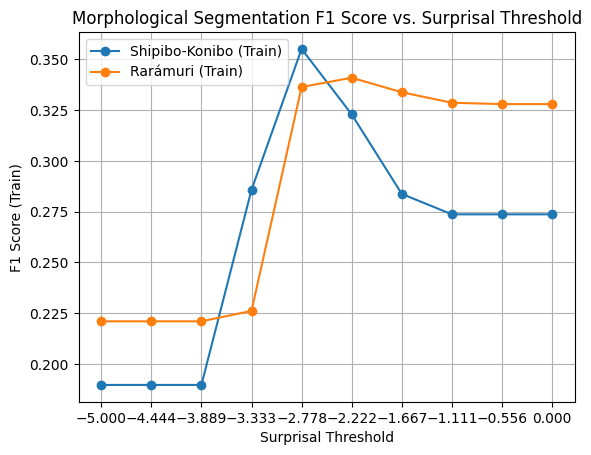

Best Shipibo-Konibo threshold: -2.78, F1 score: 0.3551
Best Rarámuri threshold: -2.22, F1 score: 0.3409


In [65]:
def test_segmentation(language, split='dev', surprisal_threshold=-3, vb=False, n=4):
    src = data[language][split]['src']
    tgt = data[language][split]['tgt']

    model = NGramModel(surprisal_threshold=surprisal_threshold, n=n)
    model.fit(src)

    predictions = [model.segment_word(word) for word in src]
    f1_score = run_eval(tgt, predictions)

    if vb: 
        print(f'{language}.{split} F1 score: {f1_score:.4f}')
    return f1_score

# test_segmentation('shp', 'dev')
# test_segmentation('shp', 'train')
# test_segmentation('tar', 'dev')
# test_segmentation('tar', 'train')

shp_train_results = {}
tar_train_results = {}

thresholds = np.linspace(-5, 0, 10)

for surprisal_threshold in thresholds:
    shp_train_results[surprisal_threshold] = test_segmentation('shp', 'train', surprisal_threshold=surprisal_threshold)
    tar_train_results[surprisal_threshold] = test_segmentation('tar', 'train', surprisal_threshold=surprisal_threshold)

plt.plot(thresholds, [shp_train_results[t] for t in thresholds], marker='o', label='Shipibo-Konibo (Train)')
plt.plot(thresholds, [tar_train_results[t] for t in thresholds], marker='o', label='Rarámuri (Train)')

plt.xlabel('Surprisal Threshold')
plt.ylabel('F1 Score (Train)')
plt.title('Morphological Segmentation F1 Score vs. Surprisal Threshold')
plt.xticks(thresholds)
plt.legend()
plt.grid(True)
plt.show()

best_shp_threshold = max(shp_train_results, key=shp_train_results.get)
best_tar_threshold = max(tar_train_results, key=tar_train_results.get)

print(f'Best Shipibo-Konibo threshold: {best_shp_threshold:.2f}, F1 score: {shp_train_results[best_shp_threshold]:.4f}')
print(f'Best Rarámuri threshold: {best_tar_threshold:.2f}, F1 score: {tar_train_results[best_tar_threshold]:.4f}')

## ML Approach

Now, let's try throwing ML at this problem. We can consider morphological segmentation as a sequence labeling problem, were we label each letter as either the beginning of a morpheme or not.

I will use a transformer encoder to encode the input sequence and then a linear layer to predict the label of each letter.